In [70]:
import pandas as pd
import numpy as np
import time
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    results = {
        'Model': name,
        'Training Time (s)': round(train_time, 4),
        'Training MAE': mean_absolute_error(y_train, y_pred_train),
        'Training MSE': mean_squared_error(y_train, y_pred_train),
        'Training RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Training R²': r2_score(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Test MSE': mean_squared_error(y_test, y_pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Test R²': r2_score(y_test, y_pred_test),
        'Feature Importances': None
    }

    # Feature importance / coefficients
    if hasattr(model, 'feature_importances_'):
        results['Feature Importances'] = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
    elif hasattr(model, 'coef_'):
        # Handle LinearRegression or Polynomial
        # For Polynomial, feature names might be generic like x0^2, etc.
        if hasattr(X_train, 'columns'):
            feature_names = X_train.columns
        else:
            feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
        results['Feature Importances'] = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': model.coef_
        }).sort_values(by='Coefficient', key=abs, ascending=False)
    
    return results

def evaluate_baseline(y_train, y_test):
    mean_pred_train = np.full_like(y_train, y_train.mean())
    mean_pred_test = np.full_like(y_test, y_train.mean())
    
    results = {
        'Model': 'Baseline (Mean Predictor)',
        'Training Time (s)': 0.0,
        'Training MAE': mean_absolute_error(y_train, mean_pred_train),
        'Training MSE': mean_squared_error(y_train, mean_pred_train),
        'Training RMSE': np.sqrt(mean_squared_error(y_train, mean_pred_train)),
        'Training R²': r2_score(y_train, mean_pred_train),
        'Test MAE': mean_absolute_error(y_test, mean_pred_test),
        'Test MSE': mean_squared_error(y_test, mean_pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, mean_pred_test)),
        'Test R²': r2_score(y_test, mean_pred_test),
        'Feature Importances': None
    }
    return results

# Models
models = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('Elastic Net', ElasticNet(random_state=42)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
]

# Evaluate
results = []
results.append(evaluate_baseline(y_train, y_test))

for name, model in models:
    results.append(evaluate_model(name, model, X_train, X_test, y_train, y_test))

# Polynomial Regression
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression()
results.append(evaluate_model('Polynomial Regression', poly_model, X_train_poly, X_test_poly, y_train, y_test))

# Results DataFrame
results_df = pd.DataFrame([{k:v for k,v in r.items() if k != 'Feature Importances'} for r in results])
display(results_df)
results_df.to_csv("./results/results.csv", index=False)


,Model,Training Time (s),Training MAE,Training MSE,Training RMSE,Training R²,Test MAE,Test MSE,Test RMSE,Test R²
0,Baseline (Mean Predictor),0.0000,66.448154,6076.398013,77.951254,0.000000,64.006461,5361.533457,73.222493,-0.011963
1,Linear Regression,0.0010,43.483504,2868.549703,53.558843,0.527919,42.794095,2900.193628,53.853446,0.452603
2,Random Forest,0.1520,17.406544,460.493093,21.459103,0.924216,44.053034,2952.010589,54.332408,0.442823
3,Elastic Net,0.0010,66.162804,6022.308348,77.603533,0.008902,63.705901,5311.212822,72.878068,-0.002465
4,Gradient Boosting,0.0674,25.351693,997.121123,31.577225,0.835903,44.603297,2898.436673,53.837131,0.452934
5,Polynomial Regression,0.0026,39.142610,2393.138618,48.919716,0.606158,43.581693,3096.028307,55.641965,0.415640


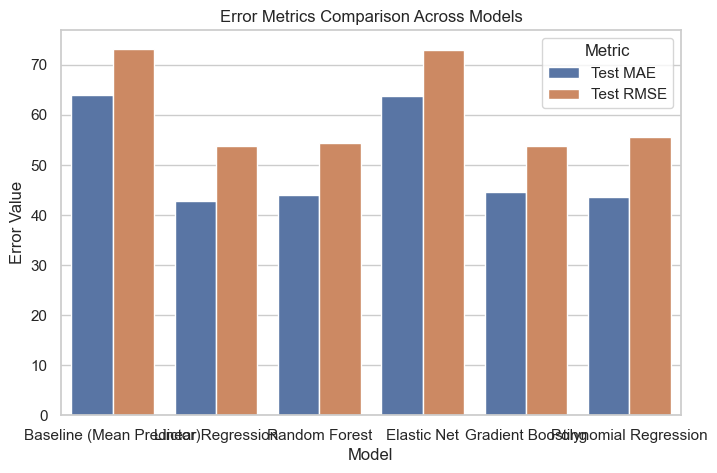

<Figure size 640x480 with 0 Axes>

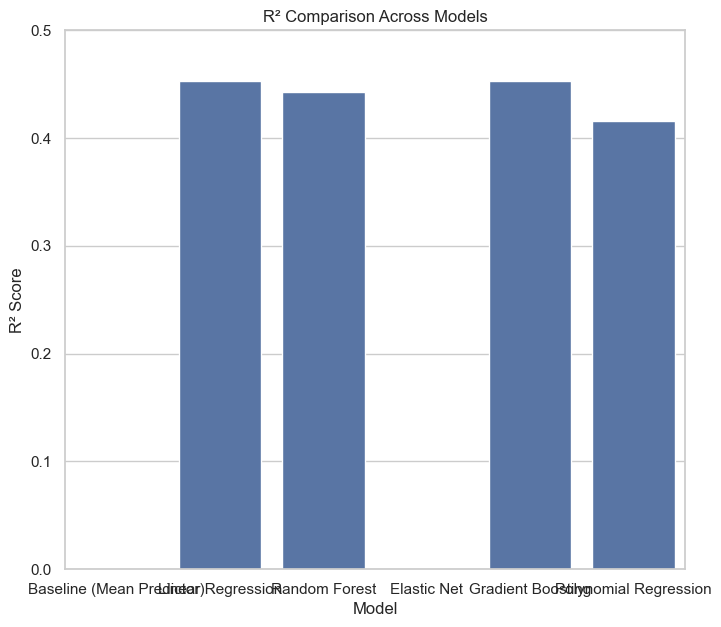

<Figure size 640x480 with 0 Axes>

In [ ]:

error_metrics = ['Test MAE', 'Test RMSE']
r2_metrics = ['Test R²']

melted_errors = results_df.melt(id_vars='Model', value_vars=error_metrics,
                                var_name='Metric', value_name='Value')

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Value', hue='Metric', data=melted_errors)
plt.title("Error Metrics Comparison Across Models")
plt.ylabel("Error Value")
plt.show()
plt.savefig("./results/figures/sdaasdfasdfsdf.png")

melted_r2 = results_df.melt(id_vars='Model', value_vars=r2_metrics,
                            var_name='Metric', value_name='Value')

plt.figure(figsize=(8,7))
sns.barplot(x='Model', y='Value', data=melted_r2)
plt.title("R² Comparison Across Models")
plt.ylabel("R² Score")
plt.ylim(0,0.5)
plt.show()


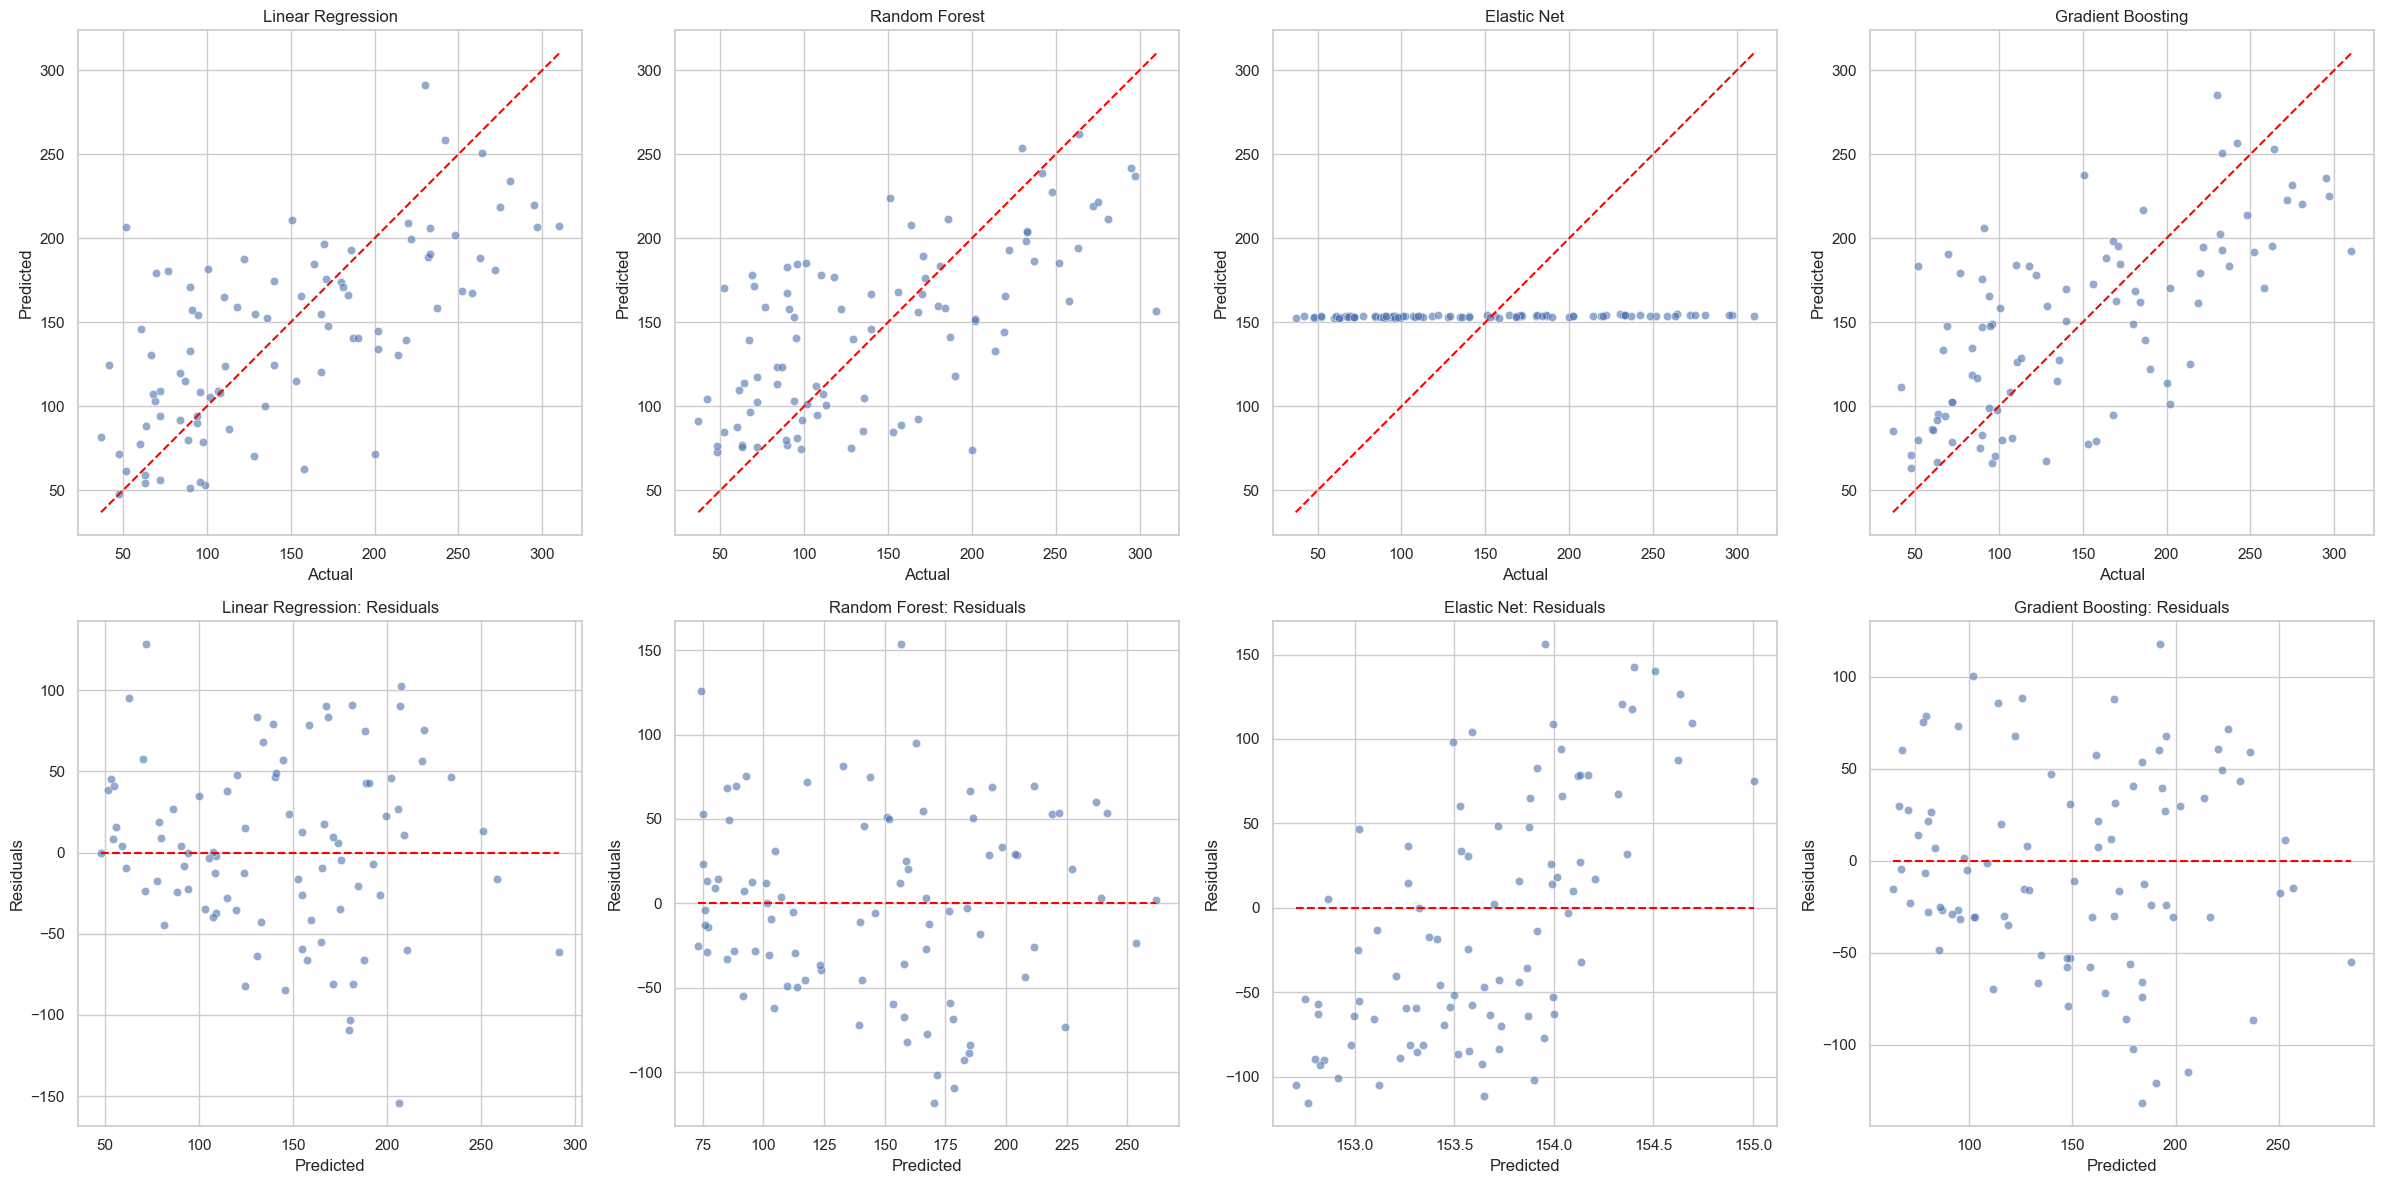

In [ ]:

def plot_models_grid(models, X_train, X_test, y_train, y_test):
    n_models = len(models)
    
    fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 12))
    
    for i, (name, model) in enumerate(models):
        model.fit(X_train, y_train)
        y_pred_test = model.predict(X_test)
        residuals = y_test - y_pred_test
        
        # Predicted vs Actual
        ax1 = axes[0, i] if n_models > 1 else axes[0]
        sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6, ax=ax1)
        sns.lineplot(x=y_test, y=y_test, color='red', linestyle='--', ax=ax1)
        ax1.set_title(f"{name}")
        ax1.set_xlabel("Actual")
        ax1.set_ylabel("Predicted")
        
        # Residuals
        ax2 = axes[1, i] if n_models > 1 else axes[1]
        sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.6, ax=ax2)
        sns.lineplot(x=[y_pred_test.min(), y_pred_test.max()], y=[0,0], color='red', linestyle='--', ax=ax2)
        ax2.set_title(f"{name}: Residuals")
        ax2.set_xlabel("Predicted")
        ax2.set_ylabel("Residuals")
    
    plt.tight_layout()
    plt.savefig("asdfasdf.png")
    plt.show()
    
plot_models_grid(models, X_train, X_test, y_train, y_test)





=== Linear Regression Feature Importances / Coefficients ===


,Feature,Coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


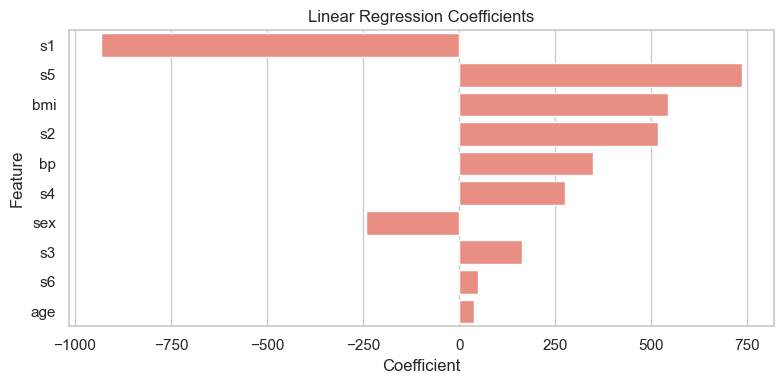


=== Random Forest Feature Importances / Coefficients ===


,Feature,Importance
2,bmi,0.355469
8,s5,0.230957
3,bp,0.088408
9,s6,0.071329
0,age,0.058642
5,s2,0.057227
4,s1,0.052784
6,s3,0.051339
7,s4,0.024213
1,sex,0.009633


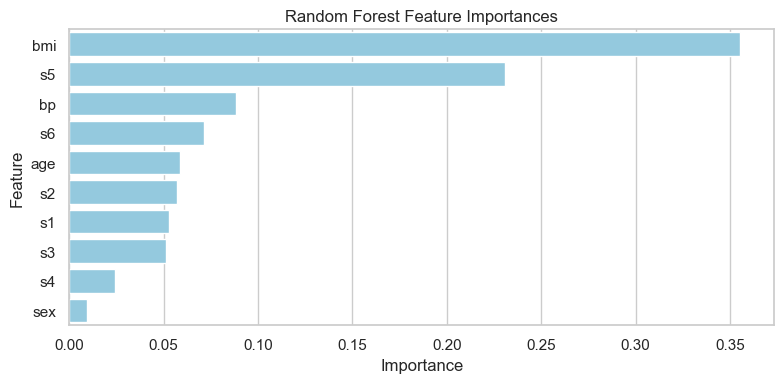


=== Elastic Net Feature Importances / Coefficients ===


,Feature,Coefficient
2,bmi,3.413534
8,s5,3.071391
3,bp,2.326144
7,s4,2.124010
9,s6,1.906183
6,s3,-1.783112
4,s1,0.459577
0,age,0.401004
5,s2,0.125552
1,sex,0.000000


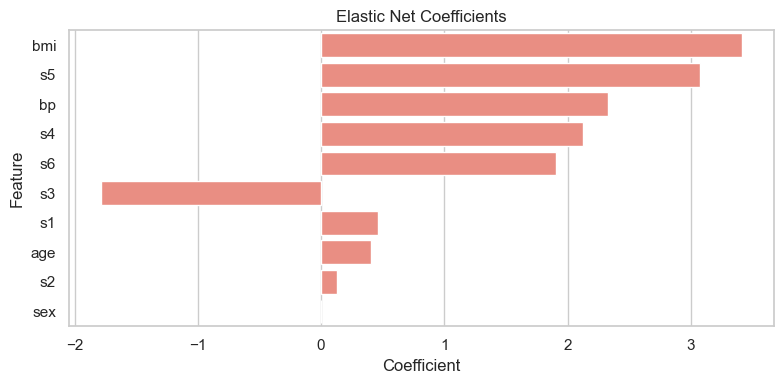


=== Gradient Boosting Feature Importances / Coefficients ===


,Feature,Importance
2,bmi,0.393101
8,s5,0.249583
3,bp,0.082979
5,s2,0.061490
0,age,0.049612
9,s6,0.046681
4,s1,0.038892
6,s3,0.036588
7,s4,0.028596
1,sex,0.012478


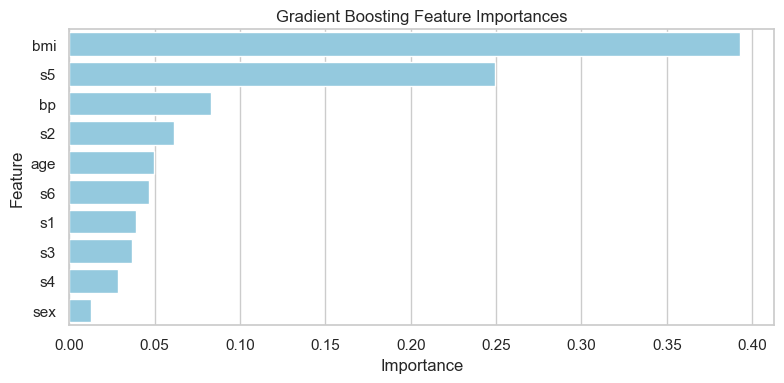


=== Polynomial Regression Feature Importances / Coefficients ===


,Feature,Coefficient
45,feature_45,-128756.526561
44,feature_44,93389.151757
46,feature_46,-61554.050838
50,feature_50,45682.471825
48,feature_48,-40293.436034
51,feature_51,34453.904406
62,feature_62,32935.160987
47,feature_47,-25238.391169
53,feature_53,23659.351007
38,feature_38,19931.747701


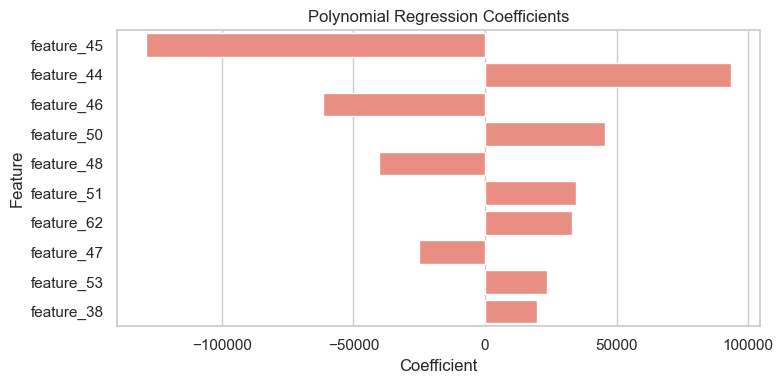

In [73]:
def show_feature_importances(results, top_n=10):
    i=0
    for r in results:
        fi = r['Feature Importances']
        if fi is not None:
            print(f"\n=== {r['Model']} Feature Importances / Coefficients ===")
            
            # Display top N in a table
            display(fi.head(top_n))
            
            # Plot
            plt.figure(figsize=(8,4))
            if 'Importance' in fi.columns:
                sns.barplot(x='Importance', y='Feature', data=fi.head(top_n), color='skyblue')
                plt.title(f"{r['Model']} Feature Importances")
            else:
                sns.barplot(x='Coefficient', y='Feature', data=fi.head(top_n), color='salmon')
                plt.title(f"{r['Model']} Coefficients")
            plt.tight_layout()
            plt.savefig(f"./results/figures/{i}.png")
            plt.show()
            i+=1
            



show_feature_importances(results, top_n=10)



In [ ]:
def average_feature_summary(results):
    coef_list = []
    importance_list = []

    for r in results:
        fi = r['Feature Importances']
        if fi is not None:
            if 'Coefficient' in fi.columns:
                temp = fi.copy()
                temp['Model'] = r['Model']
                coef_list.append(temp[['Feature', 'Coefficient']])
            elif 'Importance' in fi.columns:
                temp = fi.copy()
                temp['Model'] = r['Model']
                importance_list.append(temp[['Feature', 'Importance']])
    
    # Combine and compute average coefficients
    if coef_list:
        coef_df = pd.concat(coef_list)
        avg_coef = coef_df.groupby('Feature')['Coefficient'].mean().reset_index().sort_values(by='Coefficient', key=abs, ascending=False)
    else:
        avg_coef = pd.DataFrame()

    # Combine and compute average importances
    if importance_list:
        imp_df = pd.concat(importance_list)
        avg_imp = imp_df.groupby('Feature')['Importance'].mean().reset_index().sort_values(by='Importance', ascending=False)
    else:
        avg_imp = pd.DataFrame()

    # Merge both into a single table
    summary_df = pd.merge(avg_coef, avg_imp, on='Feature', how='outer')
    summary_df = summary_df.fillna(0)  # Replace NaN with 0
    return summary_df

# Usage
avg_summary = average_feature_summary(results)
display(avg_summary)


,Feature,Coefficient,Importance
0,age,19.152513,0.054127
1,bmi,272.921146,0.374285
2,bp,175.014994,0.085693
3,feature_0,108.828416,0.000000
4,feature_1,-311.898491,0.000000
...,...,...,...
70,s3,80.818435,0.043963
71,s4,138.720956,0.026404
72,s5,369.635125,0.240270
73,s6,25.288420,0.059005
